<a href="https://colab.research.google.com/github/PHANNhatTien/TCAD-training/blob/main/examples/plotting/visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing DEVSIM results in a Jupyter Notebook

Excellent standalone software exist to visualize meshes on results such as [VisIt](https://visit-dav.github.io/visit-website/index.html) and [Paraview](https://www.paraview.org/).

However, it is sometimes useful to interweave code and visualization, for instance when debugging.

There are many ways to do this. Here, we use [PyVista](https://docs.pyvista.org/) with the [panel](https://panel.holoviz.org/) backend.

### Installing PyVista

You will need to install the requisite packages:

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
install_pyvista = True # True to install
package_manager = 'pip' # or 'pip'

if install_pyvista:
    if package_manager=='conda':
        %conda install --yes -c conda-forge pyvista
        %conda install --yes -c conda-forge panel
        %conda install -c conda-forge wurlitzer
    elif package_manager=='pip':
        %pip install pyvista
        %pip install panel
        %pip install wurlitzer

### Generating mesh data

A DEVSIM simulation's mesh data can be saved to a `.dat` file with the [devsim.write_devices](https://devsim.net/CommandReference.html#devsim.write_devices) function with the `type='tecplot'` argument.

In this examples directory, the `gmsh_diode2d.py` and `gmsh_diode3d.py` scripts can perform this and generate, respectively, `gmsh_diode2d.dat` and `gmsh_diode3d_dd.dat`.

In [ ]:
import os

run = True # True to run the scripts

if run:
    # Store the original working directory
    original_cwd = os.getcwd()
    # Change the working directory to where the scripts are located
    os.chdir(base_dir)
    try:
        !python gmsh_diode2d.py
        !python gmsh_diode3d.py
    finally:
        # Change back to the original working directory
        os.chdir(original_cwd)

Physical group name Base has 0 Tetrahedra.
Physical group name Base has 0 Triangles.
Physical group name Base has 19 Lines.
Physical group name Base has 20 Points.
Physical group name Bulk has 0 Tetrahedra.
Physical group name Bulk has 922 Triangles.
Physical group name Bulk has 1422 Lines.
Physical group name Bulk has 501 Points.
Physical group name Emitter has 0 Tetrahedra.
Physical group name Emitter has 0 Triangles.
Physical group name Emitter has 20 Lines.
Physical group name Emitter has 21 Points.
Device diode2d has 501 coordinates with max index 501
Region Bulk has 501 nodes.
Contact bot in region Bulk with 21 nodes
Contact top in region Bulk with 20 nodes
number of equations 501
Iteration: 0
  Device: "diode2d"	RelError: 1.00000e+00	AbsError: 8.93836e-02
    Region: "Bulk"	RelError: 1.00000e+00	AbsError: 8.93836e-02
      Equation: "PotentialEquation"	RelError: 1.00000e+00	AbsError: 8.93836e-02
Iteration: 1
  Device: "diode2d"	RelError: 4.91460e-01	AbsError: 8.63816e-02
    Reg

### 2D Visualization

We can load the `.dat` data and visualize it in the notebook. Specifically, we will load the `xy` plane, and display the "Electrons" field:

In [ ]:
import pyvista as pv
from wurlitzer import pipes # To suppress some vtk output

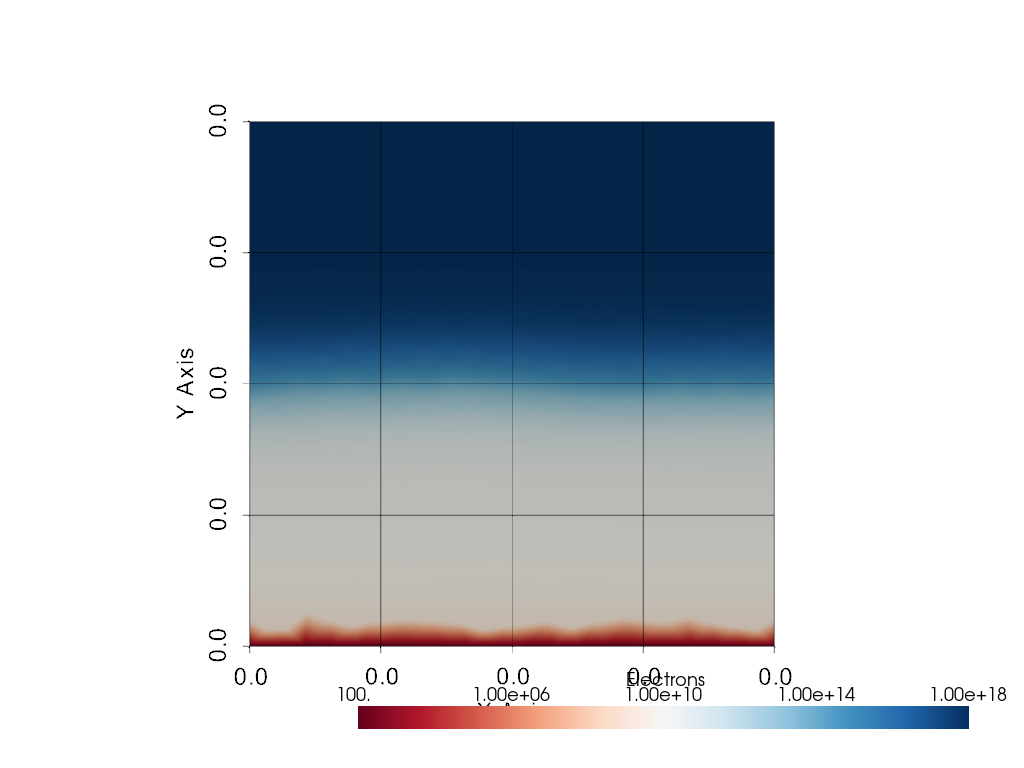

In [ ]:
import os

with pipes() as (out, err):
    reader = pv.get_reader(os.path.join(base_dir, 'gmsh_diode2d.dat'))
    mesh = reader.read()
    plotter = pv.Plotter(notebook=True)
    _ = plotter.add_mesh(mesh, scalars='Electrons', log_scale=True, cmap='RdBu')
    _ = plotter.show_grid()
    _ = plotter.camera_position = "xy"
    _ = plotter.show(jupyter_backend='panel')

### 3D Visualization

In 3D, we choose the `panel` backend for interactive visualization:

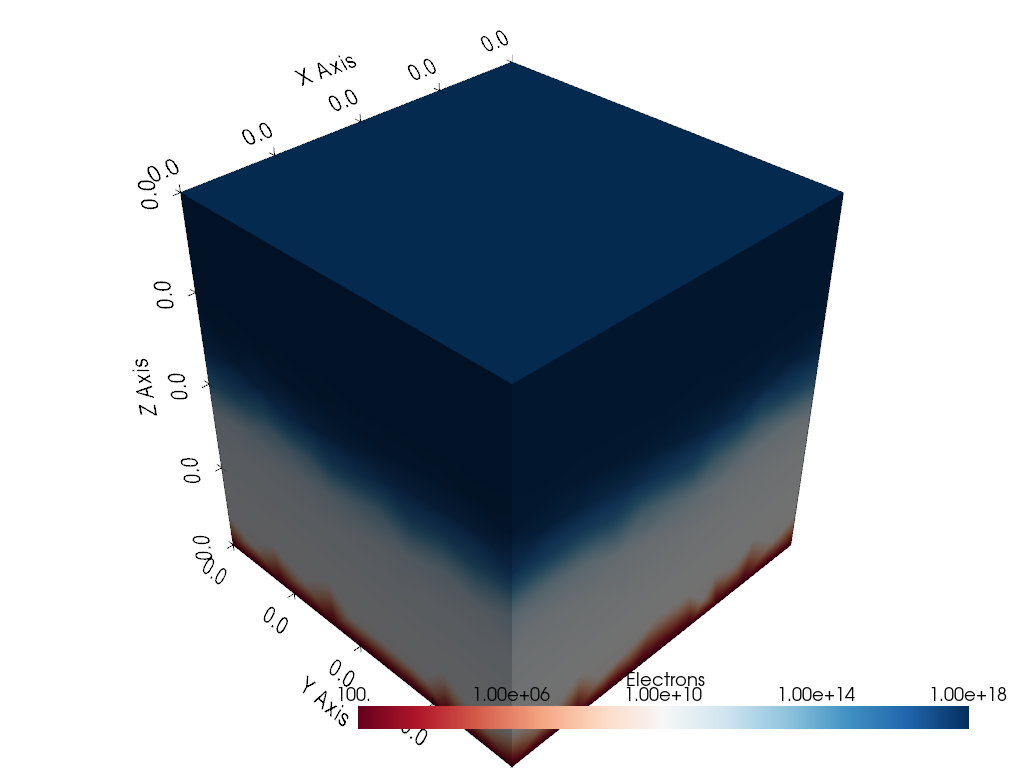

In [ ]:
import os

with pipes() as (out, err):
    reader = pv.get_reader(os.path.join(base_dir, 'gmsh_diode3d_dd.dat'))
    mesh = reader.read()
    plotter = pv.Plotter(notebook=True)
    _ = plotter.add_mesh(mesh, scalars='Electrons', log_scale=True, cmap='RdBu')
    _ = plotter.show_grid()
    _ = plotter.show(jupyter_backend='panel')

### Going further

There are many more plotting options and examples in the [pyvista examples](https://docs.pyvista.org/examples/index.html).

In [ ]:
# Building the 2d planar MOSFET structure
#
# Design scenario:  Bulk Si -> STI -> PWELL -> NWELL -> Dummygate -> Halo -> SiN spacer -> SDE -> Epi SiGe S/D PMOS -> S/D NMOS -> CESL
#


